# Assignment 10
#### Problem statement:-Implementing Self-Organizing Maps (SOM) for Image Compression-
##### a. Implement Kohonens Self-Organizing Map (SOM) for image compression.
##### b. Train the SOM to reduce the number of colors in an image.
##### c. Display the original and compressed images to analyze quality loss.
## Student Name: Aarti P. Kalyane
## Roll No.: EN231070055
## Batch: B
## Subject: AI&NN

In [1]:
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
pip install pillow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\SANKALP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [4]:
pip install minisom

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for minisom: filename=minisom-2.3.5-py3-none-any.whl size=12132 sha256=8917c2dd13f93ef604411645be2644e427a15df365bf1eb656201ca681022539
  Stored in directory: c:\users\sankalp\appdata\local\pip\cache\wheels\0f\8c\a4\5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\SANKALP\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
from minisom import MiniSom

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from minisom import MiniSom

In [7]:
def compress_image_with_som(image_path, som_size=16, iterations=1000):
    # Load and normalize image
    img = Image.open(image_path).convert('RGB')
    img_np = np.array(img) / 255.0  # Normalize pixel values to [0,1]
    
    # Flatten image pixels for SOM training
    pixels = img_np.reshape(-1, 3)
    
    # Initialize MiniSOM
    som = MiniSom(som_size, som_size, 3, sigma=1.0, learning_rate=0.5, neighborhood_function='gaussian', random_seed=42)
    
    print("Training SOM... This may take some time depending on image size and iterations.")
    som.train_random(pixels, iterations)
    
    # Create compressed image by replacing each pixel color with BMU's weight
    compressed_img = np.zeros_like(img_np)
    for i in range(img_np.shape[0]):
        for j in range(img_np.shape[1]):
            pixel = img_np[i, j]
            winner = som.winner(pixel)
            compressed_img[i, j] = som.get_weights()[winner]
    
    return img_np, compressed_img

In [8]:
def display_images(original, compressed):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    axes[1].imshow(compressed)
    axes[1].set_title("Compressed Image")
    axes[1].axis('off')
    
    plt.show()

Training SOM... This may take some time depending on image size and iterations.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27083977225640105..0.9995118957447136].


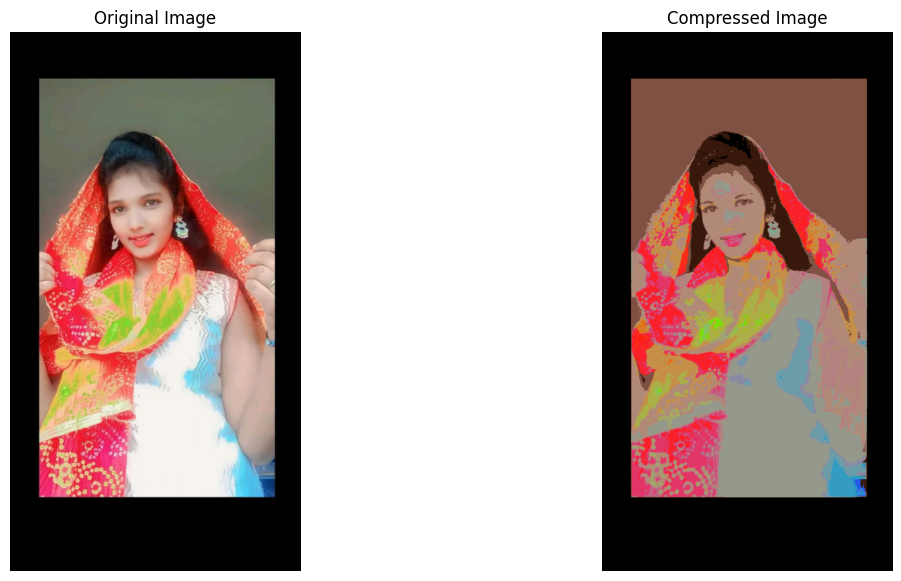

In [11]:
if __name__ == "__main__":
    # Path to your image file — change this to your own image path!
    image_path = "C:\\Users\\SANKALP\\OneDrive\\Pictures\\sanskruti.jpg"
    
    # You can adjust som_size and iterations for better quality or speed
    som_size = 16      # SOM grid size (16x16 = 256 colors)
    iterations = 3000  # Number of training iterations
    
    original_img, compressed_img = compress_image_with_som(image_path, som_size, iterations)
    display_images(original_img, compressed_img)
